In [1]:
!pip -q install ucimlrepo xgboost shap lime openpyxl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 15.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 MB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 498.0/498.0 kB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.9/250.9 kB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 305.1/305.1 MB 11.7 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings("ignore")

import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.base import clone
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV,
    cross_validate,
    cross_val_predict
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    brier_score_loss,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)
from sklearn.calibration import calibration_curve

from xgboost import XGBClassifier

from scipy.stats import spearmanr

import shap
from lime.lime_tabular import LimeTabularExplainer

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print("Ortam hazır.")

Ortam hazır.


In [3]:
dataset = fetch_ucirepo(id=350)

X = dataset.data.features.copy()
y = dataset.data.targets.copy()

print("X boyutu:", X.shape)
print("y boyutu:", y.shape)

display(X.head())
display(y.head())

X boyutu: (30000, 23)
y boyutu: (30000, 1)


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679


,Y
0,1
1,1
2,0
3,0
4,0


In [4]:
y = y.iloc[:, 0].astype(int)

print("Hedef değişken:", y.name)
print("\nSınıf dağılımı:")
print(y.value_counts())

print("\nOransal dağılım:")
print(y.value_counts(normalize=True))

Hedef değişken: Y

Sınıf dağılımı:
Y
0    23364
1     6636
Name: count, dtype: int64

Oransal dağılım:
Y
0    0.7788
1    0.2212
Name: proportion, dtype: float64


In [5]:
if "ID" in X.columns:
    X = X.drop(columns=["ID"])

X.columns = [
    "LIMIT_BAL",
    "SEX",
    "EDUCATION",
    "MARRIAGE",
    "AGE",
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6",
    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6",
    "PAY_AMT1",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6"
]

display(X.head())

print("\nSütunlar:")
print(X.columns.tolist())

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679



Sütunlar:
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


In [6]:
print("Eksik değer toplamı:", X.isna().sum().sum())
print("Tekrarlanan satır sayısı:", X.duplicated().sum())

print("\nVeri türleri:")
print(X.dtypes)

print("\nHedef dağılımı:")
print(y.value_counts())

Eksik değer toplamı: 0
Tekrarlanan satır sayısı: 56

Veri türleri:
LIMIT_BAL    int64
SEX          int64
EDUCATION    int64
MARRIAGE     int64
AGE          int64
PAY_0        int64
PAY_2        int64
PAY_3        int64
PAY_4        int64
PAY_5        int64
PAY_6        int64
BILL_AMT1    int64
BILL_AMT2    int64
BILL_AMT3    int64
BILL_AMT4    int64
BILL_AMT5    int64
BILL_AMT6    int64
PAY_AMT1     int64
PAY_AMT2     int64
PAY_AMT3     int64
PAY_AMT4     int64
PAY_AMT5     int64
PAY_AMT6     int64
dtype: object

Hedef dağılımı:
Y
0    23364
1     6636
Name: count, dtype: int64


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training:", X_train.shape)
print("Test:", X_test.shape)

print("\nTrain default oranı:")
print(y_train.mean())

print("\nTest default oranı:")
print(y_test.mean())

Training: (24000, 23)
Test: (6000, 23)

Train default oranı:
0.22120833333333334

Test default oranı:
0.22116666666666668


In [8]:
n_negative = (y_train == 0).sum()
n_positive = (y_train == 1).sum()

scale_pos_weight = n_negative / n_positive

print("Negative:", n_negative)
print("Positive:", n_positive)
print("scale_pos_weight:", round(scale_pos_weight, 4))

Negative: 18691
Positive: 5309
scale_pos_weight: 3.5206


In [9]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ]),

    "Random Forest": RandomForestClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

In [10]:
param_distributions = {

    "Logistic Regression": {
        "clf__C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100],
        "clf__penalty": ["l1", "l2"],
        "clf__solver": ["liblinear"]
    },

    "Random Forest": {
        "n_estimators": [200, 300, 500, 700, 1000],
        "max_depth": [None, 5, 8, 10, 15, 20],
        "min_samples_split": [2, 5, 10, 20],
        "min_samples_leaf": [1, 2, 4, 8],
        "max_features": ["sqrt", "log2", 0.5]
    },

    "XGBoost": {
        "n_estimators": [200, 300, 500, 700],
        "max_depth": [3, 4, 5, 6, 8],
        "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.10],
        "subsample": [0.7, 0.8, 0.9, 1.0],
        "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
        "min_child_weight": [1, 3, 5, 7],
        "gamma": [0, 0.1, 0.3, 0.5],
        "reg_lambda": [0.5, 1, 2, 5, 10]
    }
}

In [11]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [12]:
N_ITER = {
    "Logistic Regression": 20,
    "Random Forest": 40,
    "XGBoost": 50
}

best_estimators = {}
search_results = {}

for name, model in models.items():

    print("\n" + "=" * 70)
    print("Tuning:", name)
    print("=" * 70)

    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_distributions[name],
        n_iter=N_ITER[name],
        scoring="roc_auc",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    search.fit(X_train, y_train)

    best_estimators[name] = search.best_estimator_
    search_results[name] = search

    print("Best CV ROC-AUC:", round(search.best_score_, 6))
    print("Best parameters:")
    print(search.best_params_)


Tuning: Logistic Regression
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best CV ROC-AUC: 0.726514
Best parameters:
{'clf__solver': 'liblinear', 'clf__penalty': 'l1', 'clf__C': 3}

Tuning: Random Forest
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best CV ROC-AUC: 0.783857
Best parameters:
{'n_estimators': 700, 'min_samples_split': 2, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'max_depth': 15}

Tuning: XGBoost
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best CV ROC-AUC: 0.785075
Best parameters:
{'subsample': 0.7, 'reg_lambda': 0.5, 'n_estimators': 700, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.7}


In [13]:
hyperparam_rows = []

for model_name, search in search_results.items():

    for param_name, selected_value in search.best_params_.items():

        clean_name = param_name.replace("clf__", "")

        search_space = param_distributions[model_name][param_name]

        hyperparam_rows.append({
            "Model": model_name,
            "Hyperparameter": clean_name,
            "Search Space": str(search_space),
            "Selected Value": str(selected_value)
        })

hyperparameter_table = pd.DataFrame(hyperparam_rows)

display(hyperparameter_table)

,Model,Hyperparameter,Search Space,Selected Value
0,Logistic Regression,solver,['liblinear'],liblinear
1,Logistic Regression,penalty,"['l1', 'l2']",l1
2,Logistic Regression,C,"[0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100]",3
3,Random Forest,n_estimators,"[200, 300, 500, 700, 1000]",700
4,Random Forest,min_samples_split,"[2, 5, 10, 20]",2
5,Random Forest,min_samples_leaf,"[1, 2, 4, 8]",8
6,Random Forest,max_features,"['sqrt', 'log2', 0.5]",sqrt
7,Random Forest,max_depth,"[None, 5, 8, 10, 15, 20]",15
8,XGBoost,subsample,"[0.7, 0.8, 0.9, 1.0]",0.7
9,XGBoost,reg_lambda,"[0.5, 1, 2, 5, 10]",0.5


In [14]:
hyperparameter_table.to_csv(
    "Table_Hyperparameter_Search.csv",
    index=False
)

In [15]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_rows = []

for name, estimator in best_estimators.items():

    scores = cross_validate(
        estimator,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    row = {
        "Model": name
    }

    for metric in scoring.keys():
        values = scores[f"test_{metric}"]

        row[f"{metric}_mean"] = np.mean(values)
        row[f"{metric}_std"] = np.std(values)

    cv_rows.append(row)

cv_results_df = pd.DataFrame(cv_rows)

display(cv_results_df)

,Model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,Logistic Regression,0.691625,0.010568,0.383391,0.011918,0.646267,0.016117,0.481189,0.012369,0.726514,0.010761
1,Random Forest,0.793708,0.003242,0.532124,0.007117,0.559806,0.008064,0.545571,0.005844,0.783857,0.005358
2,XGBoost,0.767042,0.003342,0.479561,0.005729,0.623661,0.010222,0.542193,0.007366,0.785075,0.006432


In [16]:
oof_probabilities = {}

for name, estimator in best_estimators.items():

    print("OOF predictions:", name)

    oof_prob = cross_val_predict(
        estimator,
        X_train,
        y_train,
        cv=cv,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    oof_probabilities[name] = oof_prob

OOF predictions: Logistic Regression
OOF predictions: Random Forest
OOF predictions: XGBoost


In [17]:
def find_best_f1_threshold(y_true, probabilities):

    precision, recall, thresholds = precision_recall_curve(
        y_true,
        probabilities
    )

    f1_scores = (
        2 * precision * recall /
        (precision + recall + 1e-12)
    )

    best_idx = np.argmax(f1_scores[:-1])

    return {
        "threshold": thresholds[best_idx],
        "precision": precision[best_idx],
        "recall": recall[best_idx],
        "f1": f1_scores[best_idx]
    }


f1_thresholds = {}

for name, probs in oof_probabilities.items():

    result = find_best_f1_threshold(
        y_train,
        probs
    )

    f1_thresholds[name] = result

    print("\n", name)
    print("Threshold:", round(result["threshold"], 4))
    print("Precision:", round(result["precision"], 4))
    print("Recall:", round(result["recall"], 4))
    print("F1:", round(result["f1"], 4))


 Logistic Regression
Threshold: 0.5803
Precision: 0.5452
Recall: 0.4862
F1: 0.514

 Random Forest
Threshold: 0.4945
Precision: 0.5288
Recall: 0.5643
F1: 0.546

 XGBoost
Threshold: 0.5179
Precision: 0.4971
Recall: 0.6071
F1: 0.5466


In [18]:
C_FP = 1
C_FN = 5

def classification_cost(
    y_true,
    probabilities,
    threshold,
    c_fp=1,
    c_fn=5
):

    pred = (probabilities >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        pred
    ).ravel()

    total_cost = c_fp * fp + c_fn * fn

    return {
        "threshold": threshold,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "total_cost": total_cost,
        "average_cost": total_cost / len(y_true)
    }

In [19]:
def find_cost_optimal_threshold(
    y_true,
    probabilities,
    c_fp=1,
    c_fn=5
):

    thresholds = np.linspace(
        0.05,
        0.95,
        181
    )

    rows = []

    for threshold in thresholds:

        result = classification_cost(
            y_true,
            probabilities,
            threshold,
            c_fp,
            c_fn
        )

        rows.append(result)

    df = pd.DataFrame(rows)

    best_row = df.loc[
        df["total_cost"].idxmin()
    ]

    return best_row, df

In [20]:
cost_thresholds = {}
cost_curves = {}

for name, probs in oof_probabilities.items():

    best_cost, cost_df = find_cost_optimal_threshold(
        y_train,
        probs,
        C_FP,
        C_FN
    )

    cost_thresholds[name] = best_cost
    cost_curves[name] = cost_df

    print("\n", name)
    print(best_cost)


 Logistic Regression
threshold           0.515000
TN              14088.000000
FP               4603.000000
FN               2061.000000
TP               3248.000000
total_cost      14908.000000
average_cost        0.621167
Name: 93, dtype: float64

 Random Forest
threshold           0.335000
TN              12193.000000
FP               6498.000000
FN               1329.000000
TP               3980.000000
total_cost      13143.000000
average_cost        0.547625
Name: 57, dtype: float64

 XGBoost
threshold           0.4350
TN              13616.0000
FP               5075.0000
FN               1589.0000
TP               3720.0000
total_cost      13020.0000
average_cost        0.5425
Name: 77, dtype: float64


In [21]:
threshold_rows = []

for name in best_estimators.keys():

    threshold_rows.append({
        "Model": name,
        "Default Threshold": 0.50,
        "F1-Optimal Threshold": f1_thresholds[name]["threshold"],
        "OOF F1 at F1-Optimal": f1_thresholds[name]["f1"],
        "Cost-Optimal Threshold": float(
            cost_thresholds[name]["threshold"]
        ),
        "OOF Minimum Cost": int(
            cost_thresholds[name]["total_cost"]
        ),
        "OOF Average Cost": float(
            cost_thresholds[name]["average_cost"]
        )
    })

threshold_summary_df = pd.DataFrame(
    threshold_rows
)

display(threshold_summary_df)

,Model,Default Threshold,F1-Optimal Threshold,OOF F1 at F1-Optimal,Cost-Optimal Threshold,OOF Minimum Cost,OOF Average Cost
0,Logistic Regression,0.5,0.580322,0.513990,0.515,14908,0.621167
1,Random Forest,0.5,0.494457,0.545968,0.335,13143,0.547625
2,XGBoost,0.5,0.517942,0.546595,0.435,13020,0.542500


In [22]:
threshold_summary_df.to_csv(
    "Table_Threshold_Selection.csv",
    index=False
)

In [23]:
from sklearn.base import clone

final_models = {}

for name, estimator in best_estimators.items():

    model = clone(estimator)

    model.fit(
        X_train,
        y_train
    )

    final_models[name] = model

print("Tüm nihai modeller eğitim setinin tamamında eğitildi.")

Tüm nihai modeller eğitim setinin tamamında eğitildi.


In [24]:
test_probabilities = {}

for name, model in final_models.items():

    test_probabilities[name] = model.predict_proba(
        X_test
    )[:, 1]

    print(
        name,
        "test probabilities oluşturuldu."
    )

Logistic Regression test probabilities oluşturuldu.
Random Forest test probabilities oluşturuldu.
XGBoost test probabilities oluşturuldu.


In [25]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    brier_score_loss,
    confusion_matrix
)

def evaluate_model_at_threshold(
    y_true,
    probabilities,
    threshold
):

    y_pred = (
        probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred
    ).ravel()

    return {
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_true,
            probabilities
        ),
        "Brier": brier_score_loss(
            y_true,
            probabilities
        ),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

In [26]:
default_test_rows = []

for name, probs in test_probabilities.items():

    result = evaluate_model_at_threshold(
        y_test,
        probs,
        threshold=0.50
    )

    result["Model"] = name

    default_test_rows.append(
        result
    )

default_test_df = pd.DataFrame(
    default_test_rows
)

display(
    default_test_df[
        [
            "Model",
            "Threshold",
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC_AUC",
            "Brier"
        ]
    ]
)

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,Brier
0,Logistic Regression,0.5,0.679333,0.366919,0.620196,0.461064,0.708069,0.208925
1,Random Forest,0.5,0.794167,0.533046,0.559156,0.545789,0.774698,0.160744
2,XGBoost,0.5,0.764167,0.474478,0.616428,0.536218,0.780127,0.177844


In [27]:
default_test_df.to_csv(
    "Table_Test_Default_Threshold.csv",
    index=False
)

In [28]:
f1_test_rows = []

for name, probs in test_probabilities.items():

    threshold = float(
        f1_thresholds[name]["threshold"]
    )

    result = evaluate_model_at_threshold(
        y_test,
        probs,
        threshold
    )

    result["Model"] = name

    f1_test_rows.append(
        result
    )

f1_test_df = pd.DataFrame(
    f1_test_rows
)

display(
    f1_test_df[
        [
            "Model",
            "Threshold",
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC_AUC",
            "Brier"
        ]
    ]
)

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,Brier
0,Logistic Regression,0.580322,0.790000,0.528414,0.469480,0.497207,0.708069,0.208925
1,Random Forest,0.494457,0.791667,0.527170,0.562924,0.544461,0.774698,0.160744
2,XGBoost,0.517942,0.777500,0.497509,0.602110,0.544835,0.780127,0.177844


In [29]:
f1_test_df.to_csv(
    "Table_Test_F1_Optimal_Threshold.csv",
    index=False
)

In [30]:
cost_test_rows = []

for name, probs in test_probabilities.items():

    threshold = float(
        cost_thresholds[name]["threshold"]
    )

    result = evaluate_model_at_threshold(
        y_test,
        probs,
        threshold
    )

    total_cost = (
        C_FP * result["FP"]
        +
        C_FN * result["FN"]
    )

    average_cost = (
        total_cost / len(y_test)
    )

    result["Model"] = name
    result["Total_Cost"] = total_cost
    result["Average_Cost"] = average_cost

    cost_test_rows.append(
        result
    )

cost_test_df = pd.DataFrame(
    cost_test_rows
)

display(
    cost_test_df[
        [
            "Model",
            "Threshold",
            "FP",
            "FN",
            "Total_Cost",
            "Average_Cost",
            "Accuracy",
            "Precision",
            "Recall",
            "F1"
        ]
    ]
)

,Model,Threshold,FP,FN,Total_Cost,Average_Cost,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.515,1214,541,3919,0.653167,0.707500,0.393000,0.592313,0.472498
1,Random Forest,0.335,1671,354,3441,0.573500,0.662500,0.368003,0.733233,0.490053
2,XGBoost,0.435,1285,427,3420,0.570000,0.714667,0.411899,0.678222,0.512528


In [31]:
cost_test_df.to_csv(
    "Table_Test_Cost_Optimal_Threshold.csv",
    index=False
)

In [32]:
default_cost_rows = []

for name, probs in test_probabilities.items():

    result = evaluate_model_at_threshold(
        y_test,
        probs,
        threshold=0.50
    )

    total_cost = (
        C_FP * result["FP"]
        +
        C_FN * result["FN"]
    )

    default_cost_rows.append({
        "Model": name,
        "Threshold": 0.50,
        "FP": result["FP"],
        "FN": result["FN"],
        "Total_Cost": total_cost,
        "Average_Cost": total_cost / len(y_test)
    })

default_cost_df = pd.DataFrame(
    default_cost_rows
)

display(default_cost_df)

,Model,Threshold,FP,FN,Total_Cost,Average_Cost
0,Logistic Regression,0.5,1420,504,3940,0.656667
1,Random Forest,0.5,650,585,3575,0.595833
2,XGBoost,0.5,906,509,3451,0.575167


In [33]:
economic_comparison_rows = []

for name in final_models.keys():

    default_row = default_cost_df[
        default_cost_df["Model"] == name
    ].iloc[0]

    optimal_row = cost_test_df[
        cost_test_df["Model"] == name
    ].iloc[0]

    reduction = (
        default_row["Total_Cost"]
        -
        optimal_row["Total_Cost"]
    )

    reduction_pct = (
        reduction
        /
        default_row["Total_Cost"]
        * 100
    )

    economic_comparison_rows.append({
        "Model": name,
        "Default_Threshold": 0.50,
        "Default_Cost": default_row[
            "Total_Cost"
        ],
        "Cost_Optimal_Threshold": optimal_row[
            "Threshold"
        ],
        "Optimized_Cost": optimal_row[
            "Total_Cost"
        ],
        "Cost_Reduction": reduction,
        "Cost_Reduction_%": reduction_pct
    })

economic_comparison_df = pd.DataFrame(
    economic_comparison_rows
)

display(economic_comparison_df)

,Model,Default_Threshold,Default_Cost,Cost_Optimal_Threshold,Optimized_Cost,Cost_Reduction,Cost_Reduction_%
0,Logistic Regression,0.5,3940,0.515,3919,21,0.532995
1,Random Forest,0.5,3575,0.335,3441,134,3.748252
2,XGBoost,0.5,3451,0.435,3420,31,0.898290


In [34]:
def bootstrap_auc_ci(
    y_true,
    probabilities,
    n_bootstrap=3000,
    random_state=42
):

    rng = np.random.default_rng(
        random_state
    )

    y_true_array = np.asarray(
        y_true
    )

    probabilities = np.asarray(
        probabilities
    )

    n = len(
        y_true_array
    )

    auc_values = []

    for _ in range(
        n_bootstrap
    ):

        indices = rng.integers(
            0,
            n,
            n
        )

        y_sample = y_true_array[
            indices
        ]

        if len(
            np.unique(y_sample)
        ) < 2:
            continue

        prob_sample = probabilities[
            indices
        ]

        auc_values.append(
            roc_auc_score(
                y_sample,
                prob_sample
            )
        )

    auc_values = np.asarray(
        auc_values
    )

    auc = roc_auc_score(
        y_true_array,
        probabilities
    )

    lower = np.percentile(
        auc_values,
        2.5
    )

    upper = np.percentile(
        auc_values,
        97.5
    )

    return auc, lower, upper

In [35]:
auc_ci_rows = []

for name, probs in test_probabilities.items():

    auc, lower, upper = bootstrap_auc_ci(
        y_test,
        probs,
        n_bootstrap=3000,
        random_state=RANDOM_STATE
    )

    auc_ci_rows.append({
        "Model": name,
        "ROC_AUC": auc,
        "95% CI Lower": lower,
        "95% CI Upper": upper
    })

auc_ci_df = pd.DataFrame(
    auc_ci_rows
)

display(auc_ci_df)

,Model,ROC_AUC,95% CI Lower,95% CI Upper
0,Logistic Regression,0.708069,0.690778,0.725351
1,Random Forest,0.774698,0.759296,0.789891
2,XGBoost,0.780127,0.764937,0.795374


In [36]:
auc_ci_df.to_csv(
    "Table_ROC_AUC_95CI.csv",
    index=False
)

In [37]:
def paired_bootstrap_auc_test(
    y_true,
    prob_a,
    prob_b,
    n_bootstrap=5000,
    random_state=42
):

    rng = np.random.default_rng(
        random_state
    )

    y_true = np.asarray(
        y_true
    )

    prob_a = np.asarray(
        prob_a
    )

    prob_b = np.asarray(
        prob_b
    )

    n = len(
        y_true
    )

    observed_difference = (
        roc_auc_score(
            y_true,
            prob_a
        )
        -
        roc_auc_score(
            y_true,
            prob_b
        )
    )

    differences = []

    for _ in range(
        n_bootstrap
    ):

        indices = rng.integers(
            0,
            n,
            n
        )

        y_sample = y_true[
            indices
        ]

        if len(
            np.unique(y_sample)
        ) < 2:
            continue

        auc_a = roc_auc_score(
            y_sample,
            prob_a[indices]
        )

        auc_b = roc_auc_score(
            y_sample,
            prob_b[indices]
        )

        differences.append(
            auc_a - auc_b
        )

    differences = np.asarray(
        differences
    )

    lower = np.percentile(
        differences,
        2.5
    )

    upper = np.percentile(
        differences,
        97.5
    )

    p_value = 2 * min(
        np.mean(
            differences <= 0
        ),
        np.mean(
            differences >= 0
        )
    )

    return {
        "Difference": observed_difference,
        "95% CI Lower": lower,
        "95% CI Upper": upper,
        "p-value": min(
            p_value,
            1.0
        )
    }

In [38]:
model_names = list(
    test_probabilities.keys()
)

pairwise_rows = []

for i in range(
    len(model_names)
):

    for j in range(
        i + 1,
        len(model_names)
    ):

        model_a = model_names[i]
        model_b = model_names[j]

        result = paired_bootstrap_auc_test(
            y_test,
            test_probabilities[
                model_a
            ],
            test_probabilities[
                model_b
            ],
            n_bootstrap=5000,
            random_state=RANDOM_STATE
        )

        pairwise_rows.append({
            "Model A": model_a,
            "Model B": model_b,
            **result
        })

pairwise_auc_df = pd.DataFrame(
    pairwise_rows
)

display(pairwise_auc_df)

,Model A,Model B,Difference,95% CI Lower,95% CI Upper,p-value
0,Logistic Regression,Random Forest,-0.066629,-0.080534,-0.052503,0.0000
1,Logistic Regression,XGBoost,-0.072058,-0.085539,-0.058173,0.0000
2,Random Forest,XGBoost,-0.005429,-0.009343,-0.001625,0.0044


In [39]:
pairwise_auc_df.to_csv(
    "Table_Pairwise_AUC_Tests.csv",
    index=False
)

In [40]:
def paired_bootstrap_brier_test(
    y_true,
    prob_a,
    prob_b,
    n_bootstrap=5000,
    random_state=42
):
    rng = np.random.default_rng(random_state)

    y_true = np.asarray(y_true)
    prob_a = np.asarray(prob_a)
    prob_b = np.asarray(prob_b)

    observed_a = brier_score_loss(y_true, prob_a)
    observed_b = brier_score_loss(y_true, prob_b)

    observed_diff = observed_a - observed_b

    n = len(y_true)
    differences = []

    for _ in range(n_bootstrap):

        idx = rng.integers(0, n, n)

        y_sample = y_true[idx]

        brier_a = brier_score_loss(
            y_sample,
            prob_a[idx]
        )

        brier_b = brier_score_loss(
            y_sample,
            prob_b[idx]
        )

        differences.append(
            brier_a - brier_b
        )

    differences = np.asarray(differences)

    lower = np.percentile(
        differences,
        2.5
    )

    upper = np.percentile(
        differences,
        97.5
    )

    p_value = 2 * min(
        np.mean(differences <= 0),
        np.mean(differences >= 0)
    )

    return {
        "Difference": observed_diff,
        "95% CI Lower": lower,
        "95% CI Upper": upper,
        "p-value": min(p_value, 1.0)
    }

In [41]:
brier_pairwise_rows = []

model_names = list(
    test_probabilities.keys()
)

for i in range(len(model_names)):

    for j in range(
        i + 1,
        len(model_names)
    ):

        model_a = model_names[i]
        model_b = model_names[j]

        result = paired_bootstrap_brier_test(
            y_test,
            test_probabilities[model_a],
            test_probabilities[model_b],
            n_bootstrap=5000,
            random_state=RANDOM_STATE
        )

        brier_pairwise_rows.append({
            "Model A": model_a,
            "Model B": model_b,
            **result
        })

pairwise_brier_df = pd.DataFrame(
    brier_pairwise_rows
)

display(pairwise_brier_df)

,Model A,Model B,Difference,95% CI Lower,95% CI Upper,p-value
0,Logistic Regression,Random Forest,0.048181,0.044931,0.051528,0.0
1,Logistic Regression,XGBoost,0.031081,0.027901,0.034298,0.0
2,Random Forest,XGBoost,-0.017100,-0.018578,-0.015627,0.0


In [42]:
pairwise_brier_df.to_csv(
    "Table_Pairwise_Brier_Tests.csv",
    index=False
)

In [43]:
fn_cost_ratios = [
    1,
    2,
    3,
    5,
    10
]

cost_sensitivity_rows = []

for fn_cost in fn_cost_ratios:

    for name in final_models.keys():

        # TRAIN OOF üzerinde threshold seç
        best_train_cost, _ = find_cost_optimal_threshold(
            y_train,
            oof_probabilities[name],
            c_fp=1,
            c_fn=fn_cost
        )

        selected_threshold = float(
            best_train_cost["threshold"]
        )

        # TEST üzerinde yalnız değerlendir
        test_result = classification_cost(
            y_test,
            test_probabilities[name],
            selected_threshold,
            c_fp=1,
            c_fn=fn_cost
        )

        cost_sensitivity_rows.append({
            "Model": name,
            "FN_FP_Cost_Ratio": f"1:{fn_cost}",
            "FN_Cost": fn_cost,
            "Selected_Threshold": selected_threshold,
            "FP": test_result["FP"],
            "FN": test_result["FN"],
            "Total_Cost": test_result["total_cost"],
            "Average_Cost": test_result["average_cost"]
        })

cost_sensitivity_df = pd.DataFrame(
    cost_sensitivity_rows
)

display(cost_sensitivity_df)

,Model,FN_FP_Cost_Ratio,FN_Cost,Selected_Threshold,FP,FN,Total_Cost,Average_Cost
0,Logistic Regression,1:1,1,0.690,279,848,1127,0.187833
1,Random Forest,1:1,1,0.720,219,881,1100,0.183333
2,XGBoost,1:1,1,0.730,281,803,1084,0.180667
3,Logistic Regression,1:2,2,0.610,440,748,1936,0.322667
4,Random Forest,1:2,2,0.545,547,634,1815,0.302500
5,XGBoost,1:2,2,0.625,490,663,1816,0.302667
6,Logistic Regression,1:3,3,0.580,560,704,2672,0.445333
7,Random Forest,1:3,3,0.445,854,530,2444,0.407333
8,XGBoost,1:3,3,0.515,818,525,2393,0.398833
9,Logistic Regression,1:5,5,0.515,1214,541,3919,0.653167


In [44]:
cost_pivot = cost_sensitivity_df.pivot(
    index="FN_FP_Cost_Ratio",
    columns="Model",
    values="Total_Cost"
)

display(cost_pivot)

Model,Logistic Regression,Random Forest,XGBoost
FN_FP_Cost_Ratio,,,
1:1,1127,1100,1084
1:10,4653,4255,4145
1:2,1936,1815,1816
1:3,2672,2444,2393
1:5,3919,3441,3420


In [45]:
cost_sensitivity_df.to_csv(
    "Table_Cost_Sensitivity.csv",
    index=False
)

In [46]:
def paired_bootstrap_brier_test(
    y_true,
    prob_a,
    prob_b,
    n_bootstrap=5000,
    random_state=42
):
    rng = np.random.default_rng(random_state)

    y_true = np.asarray(y_true)
    prob_a = np.asarray(prob_a)
    prob_b = np.asarray(prob_b)

    observed_diff = (
        brier_score_loss(y_true, prob_a)
        -
        brier_score_loss(y_true, prob_b)
    )

    n = len(y_true)
    differences = []

    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)

        diff = (
            brier_score_loss(y_true[idx], prob_a[idx])
            -
            brier_score_loss(y_true[idx], prob_b[idx])
        )

        differences.append(diff)

    differences = np.asarray(differences)

    lower = np.percentile(differences, 2.5)
    upper = np.percentile(differences, 97.5)

    # add-one correction: p hiçbir zaman tam 0 olmaz
    left = (np.sum(differences <= 0) + 1) / (len(differences) + 1)
    right = (np.sum(differences >= 0) + 1) / (len(differences) + 1)

    p_value = min(1.0, 2 * min(left, right))

    return {
        "Difference": observed_diff,
        "95% CI Lower": lower,
        "95% CI Upper": upper,
        "p-value": p_value
    }

In [47]:
def paired_bootstrap_cost_difference(
    y_true,
    prob_a,
    prob_b,
    threshold_a,
    threshold_b,
    c_fp=1,
    c_fn=5,
    n_bootstrap=5000,
    random_state=42
):
    rng = np.random.default_rng(random_state)

    y_true = np.asarray(y_true)
    prob_a = np.asarray(prob_a)
    prob_b = np.asarray(prob_b)

    pred_a = (prob_a >= threshold_a).astype(int)
    pred_b = (prob_b >= threshold_b).astype(int)

    def cost(y, pred):
        tn, fp, fn, tp = confusion_matrix(
            y, pred, labels=[0, 1]
        ).ravel()
        return c_fp * fp + c_fn * fn

    observed_diff = (
        cost(y_true, pred_a)
        -
        cost(y_true, pred_b)
    )

    n = len(y_true)
    diffs = []

    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)

        diff = (
            cost(y_true[idx], pred_a[idx])
            -
            cost(y_true[idx], pred_b[idx])
        )

        diffs.append(diff)

    diffs = np.asarray(diffs)

    lower = np.percentile(diffs, 2.5)
    upper = np.percentile(diffs, 97.5)

    left = (np.sum(diffs <= 0) + 1) / (len(diffs) + 1)
    right = (np.sum(diffs >= 0) + 1) / (len(diffs) + 1)

    p_value = min(
        1.0,
        2 * min(left, right)
    )

    return {
        "Cost_Difference_A_minus_B": observed_diff,
        "95% CI Lower": lower,
        "95% CI Upper": upper,
        "p-value": p_value
    }

In [48]:
cost_difference_rows = []

for fn_cost in [1, 2, 3, 5, 10]:

    rf_row = cost_sensitivity_df[
        (cost_sensitivity_df["Model"] == "Random Forest")
        &
        (cost_sensitivity_df["FN_Cost"] == fn_cost)
    ].iloc[0]

    xgb_row = cost_sensitivity_df[
        (cost_sensitivity_df["Model"] == "XGBoost")
        &
        (cost_sensitivity_df["FN_Cost"] == fn_cost)
    ].iloc[0]

    result = paired_bootstrap_cost_difference(
        y_test,
        test_probabilities["Random Forest"],
        test_probabilities["XGBoost"],
        threshold_a=float(rf_row["Selected_Threshold"]),
        threshold_b=float(xgb_row["Selected_Threshold"]),
        c_fp=1,
        c_fn=fn_cost,
        n_bootstrap=5000,
        random_state=RANDOM_STATE
    )

    result["FN_FP_Cost_Ratio"] = f"1:{fn_cost}"

    cost_difference_rows.append(result)

cost_difference_df = pd.DataFrame(
    cost_difference_rows
)

display(cost_difference_df)

,Cost_Difference_A_minus_B,95% CI Lower,95% CI Upper,p-value,FN_FP_Cost_Ratio
0,16,-9.0,41.0,0.219956,1:1
1,-1,-40.0,39.0,0.988602,1:2
2,51,5.0,96.0,0.032793,1:3
3,21,-83.0,122.0,0.685463,1:5
4,110,-30.0,250.0,0.127175,1:10


In [49]:
cost_difference_df.to_csv(
    "Table_RF_XGB_Cost_Difference_Bootstrap.csv",
    index=False
)

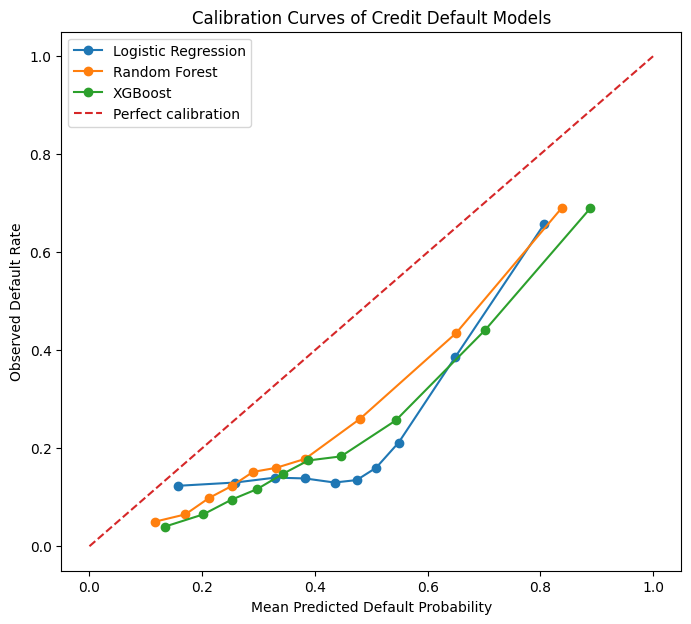

In [50]:
from sklearn.calibration import calibration_curve

plt.figure(figsize=(8, 7))

for name, probs in test_probabilities.items():

    prob_true, prob_pred = calibration_curve(
        y_test,
        probs,
        n_bins=10,
        strategy="quantile"
    )

    plt.plot(
        prob_pred,
        prob_true,
        marker="o",
        label=name
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean Predicted Default Probability")
plt.ylabel("Observed Default Rate")
plt.title("Calibration Curves of Credit Default Models")
plt.legend()

plt.savefig(
    "Figure_Calibration_Curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

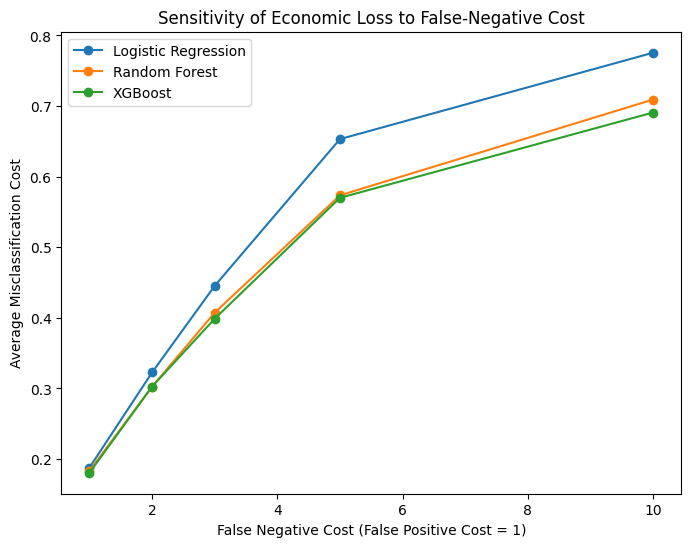

In [51]:
plt.figure(figsize=(8, 6))

for model_name in cost_sensitivity_df["Model"].unique():

    temp = cost_sensitivity_df[
        cost_sensitivity_df["Model"] == model_name
    ]

    plt.plot(
        temp["FN_Cost"],
        temp["Average_Cost"],
        marker="o",
        label=model_name
    )

plt.xlabel("False Negative Cost (False Positive Cost = 1)")
plt.ylabel("Average Misclassification Cost")
plt.title("Sensitivity of Economic Loss to False-Negative Cost")
plt.legend()

plt.savefig(
    "Figure_Cost_Sensitivity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [52]:
EXPLAIN_MODEL_NAME = "XGBoost"

explain_model = final_models[
    EXPLAIN_MODEL_NAME
]

print("Explainability model:", EXPLAIN_MODEL_NAME)

Explainability model: XGBoost


In [53]:
X_shap = X_test.sample(
    n=min(1000, len(X_test)),
    random_state=RANDOM_STATE
)

print(X_shap.shape)

(1000, 23)


In [54]:
explainer = shap.TreeExplainer(
    explain_model
)

shap_values = explainer(
    X_shap
)

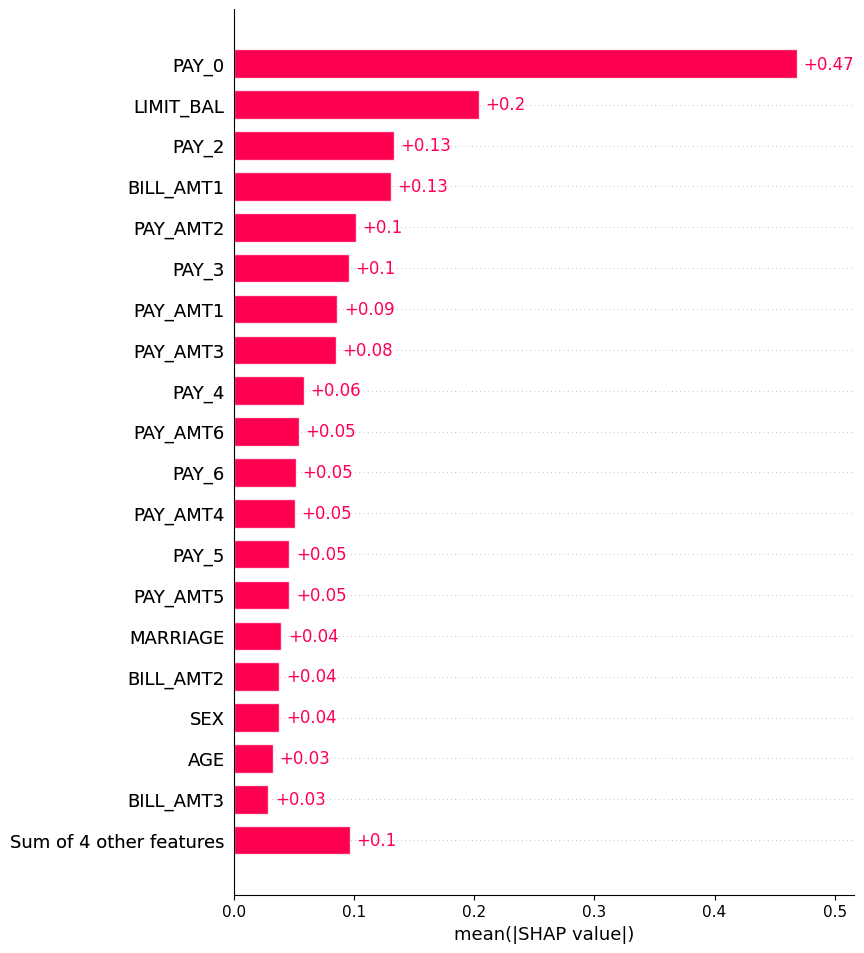

In [55]:
shap.plots.bar(
    shap_values,
    max_display=20,
    show=False
)

plt.savefig(
    "Figure_SHAP_Global_Bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

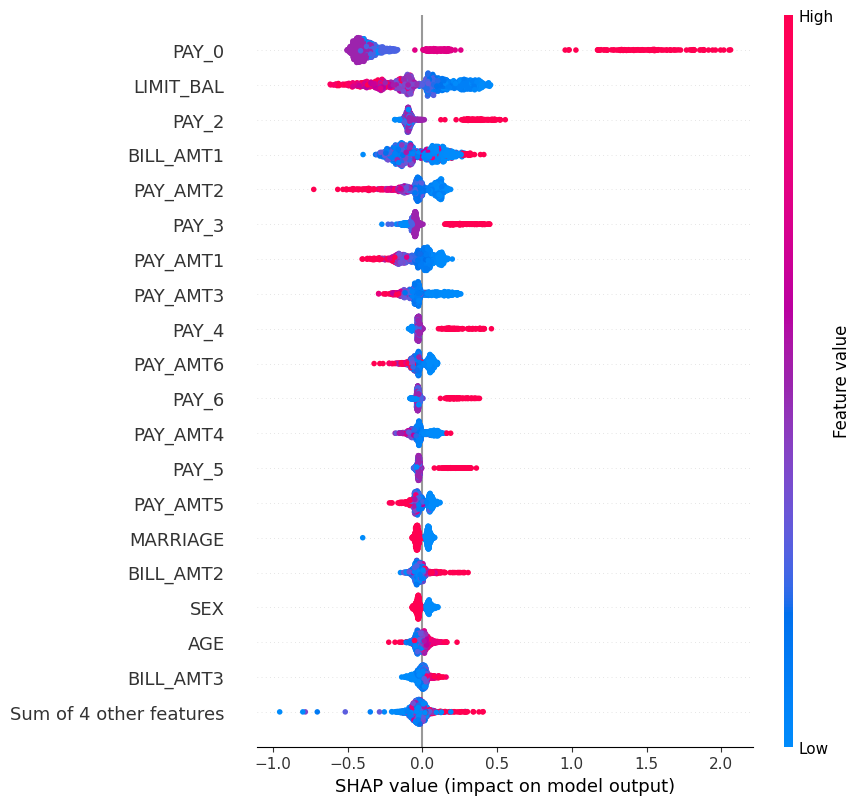

In [56]:
shap.plots.beeswarm(
    shap_values,
    max_display=20,
    show=False
)

plt.savefig(
    "Figure_SHAP_Beeswarm.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [57]:
lime_explainer = LimeTabularExplainer(
    training_data=X_train.to_numpy(),
    feature_names=X_train.columns.tolist(),
    class_names=[
        "No Default",
        "Default"
    ],
    mode="classification",
    discretize_continuous=True,
    random_state=RANDOM_STATE
)

In [58]:
def jaccard_similarity(set_a, set_b):

    set_a = set(set_a)
    set_b = set(set_b)

    union = set_a | set_b

    if len(union) == 0:
        return np.nan

    return len(
        set_a & set_b
    ) / len(union)

In [59]:
def lime_condition_to_feature(
    condition,
    feature_names
):

    matches = [
        feature
        for feature in feature_names
        if feature in condition
    ]

    if not matches:
        return None

    return max(
        matches,
        key=len
    )

In [60]:
agreement_indices = X_test.sample(
    n=100,
    random_state=RANDOM_STATE
).index

agreement_rows = []

for idx in agreement_indices:

    x_row = X_test.loc[[idx]]

    # SHAP
    sv = explainer(
        x_row
    )

    abs_values = np.abs(
        sv.values[0]
    )

    top_shap_idx = np.argsort(
        abs_values
    )[::-1][:5]

    top_shap_features = [
        X_test.columns[i]
        for i in top_shap_idx
    ]

    # LIME
    lime_exp = lime_explainer.explain_instance(
        X_test.loc[idx].to_numpy(),
        explain_model.predict_proba,
        num_features=5,
        num_samples=3000
    )

    lime_features = []

    for condition, weight in lime_exp.as_list():

        feature = lime_condition_to_feature(
            condition,
            X_test.columns
        )

        if feature is not None:
            lime_features.append(feature)

    lime_features = list(
        dict.fromkeys(lime_features)
    )[:5]

    jaccard = jaccard_similarity(
        top_shap_features,
        lime_features
    )

    probability = explain_model.predict_proba(
        x_row
    )[0, 1]

    agreement_rows.append({
        "Index": idx,
        "Probability": probability,
        "Uncertainty_Margin": abs(
            probability - 0.5
        ),
        "Jaccard": jaccard,
        "SHAP_Top5": ",".join(
            top_shap_features
        ),
        "LIME_Top5": ",".join(
            lime_features
        )
    })

agreement_df = pd.DataFrame(
    agreement_rows
)

display(
    agreement_df[
        [
            "Probability",
            "Uncertainty_Margin",
            "Jaccard"
        ]
    ].describe()
)

,Probability,Uncertainty_Margin,Jaccard
count,100.000000,100.000000,100.000000
mean,0.418962,0.221896,0.433492
std,0.239444,0.119298,0.158872
min,0.080697,0.002248,0.111111
25%,0.236066,0.132019,0.428571
50%,0.345066,0.222204,0.428571
75%,0.533610,0.313111,0.428571
max,0.953273,0.453273,1.000000


In [61]:
agreement_df.to_csv(
    "Table_SHAP_LIME_Agreement.csv",
    index=False
)

In [62]:
valid_agreement = agreement_df.dropna(
    subset=[
        "Jaccard",
        "Uncertainty_Margin"
    ]
)

rho, p_value = spearmanr(
    valid_agreement[
        "Uncertainty_Margin"
    ],
    valid_agreement[
        "Jaccard"
    ]
)

print("Spearman rho:", rho)
print("p-value:", p_value)

Spearman rho: 0.049213343308993525
p-value: 0.6267963782724962


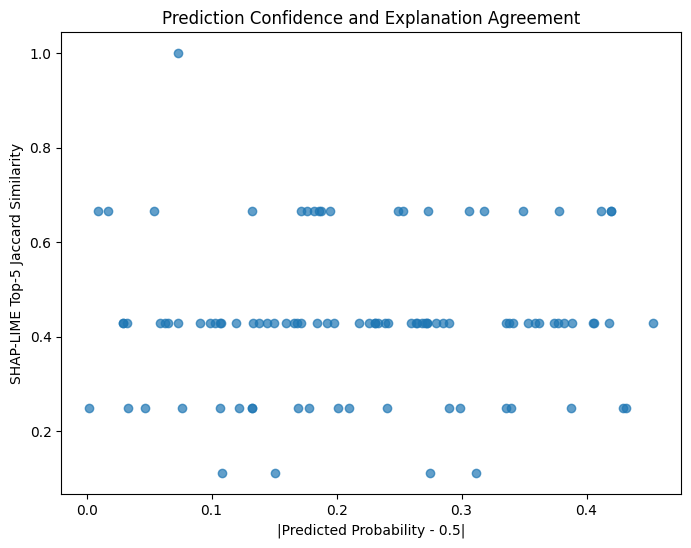

In [63]:
plt.figure(figsize=(8, 6))

plt.scatter(
    valid_agreement[
        "Uncertainty_Margin"
    ],
    valid_agreement[
        "Jaccard"
    ],
    alpha=0.7
)

plt.xlabel(
    "|Predicted Probability - 0.5|"
)

plt.ylabel(
    "SHAP-LIME Top-5 Jaccard Similarity"
)

plt.title(
    "Prediction Confidence and Explanation Agreement"
)

plt.savefig(
    "Figure_Prediction_Confidence_Explanation_Agreement.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [64]:
stability_indices = X_test.sample(
    n=10,
    random_state=RANDOM_STATE
).index

lime_stability_rows = []

for idx in stability_indices:

    feature_sets = []

    for seed in range(30):

        explainer_seed = LimeTabularExplainer(
            training_data=X_train.to_numpy(),
            feature_names=X_train.columns.tolist(),
            class_names=["No Default", "Default"],
            mode="classification",
            discretize_continuous=True,
            random_state=seed
        )

        lime_exp = explainer_seed.explain_instance(
            X_test.loc[idx].to_numpy(),
            explain_model.predict_proba,
            num_features=5,
            num_samples=3000
        )

        features = []

        for condition, weight in lime_exp.as_list():

            feature = lime_condition_to_feature(
                condition,
                X_test.columns
            )

            if feature is not None:
                features.append(feature)

        feature_sets.append(
            set(
                list(
                    dict.fromkeys(features)
                )[:5]
            )
        )

    pairwise = []

    for i in range(len(feature_sets)):
        for j in range(i + 1, len(feature_sets)):

            pairwise.append(
                jaccard_similarity(
                    feature_sets[i],
                    feature_sets[j]
                )
            )

    lime_stability_rows.append({
        "Index": idx,
        "Mean_Jaccard_Stability": np.mean(pairwise),
        "SD_Jaccard_Stability": np.std(pairwise)
    })

lime_stability_df = pd.DataFrame(
    lime_stability_rows
)

display(lime_stability_df)

,Index,Mean_Jaccard_Stability,SD_Jaccard_Stability
0,20639,0.773837,0.165426
1,7660,0.790038,0.174017
2,13980,0.742529,0.139758
3,7162,0.718008,0.137319
4,24017,0.883525,0.158929
5,499,0.852107,0.165606
6,10858,1.000000,0.000000
7,6463,0.762452,0.150843
8,17408,0.723810,0.151578
9,4619,0.806897,0.164557


In [65]:
display(
    lime_stability_df[
        [
            "Mean_Jaccard_Stability",
            "SD_Jaccard_Stability"
        ]
    ].describe()
)

,Mean_Jaccard_Stability,SD_Jaccard_Stability
count,10.000000,10.000000
mean,0.805320,0.140803
std,0.086590,0.050852
min,0.718008,0.000000
25%,0.747510,0.142529
50%,0.781938,0.155254
75%,0.840805,0.165208
max,1.000000,0.174017


In [66]:
lime_stability_df.to_csv(
    "Table_LIME_Stability.csv",
    index=False
)

In [67]:
primary_threshold = float(
    cost_thresholds["XGBoost"]["threshold"]
)

print("Primary XGBoost threshold:", primary_threshold)

Primary XGBoost threshold: 0.43499999999999994


In [68]:
def subgroup_error_table(
    X_data,
    y_true,
    probabilities,
    column,
    threshold
):

    rows = []

    y_true_series = pd.Series(
        np.asarray(y_true),
        index=X_data.index
    )

    probability_series = pd.Series(
        np.asarray(probabilities),
        index=X_data.index
    )

    for group in sorted(
        X_data[column].dropna().unique()
    ):

        mask = X_data[column] == group

        y_group = y_true_series.loc[mask]
        p_group = probability_series.loc[mask]

        pred_group = (
            p_group >= threshold
        ).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_group,
            pred_group,
            labels=[0, 1]
        ).ravel()

        fpr = (
            fp / (fp + tn)
            if (fp + tn) > 0
            else np.nan
        )

        fnr = (
            fn / (fn + tp)
            if (fn + tp) > 0
            else np.nan
        )

        recall = (
            tp / (tp + fn)
            if (tp + fn) > 0
            else np.nan
        )

        rows.append({
            "Variable": column,
            "Group": group,
            "N": len(y_group),
            "FPR": fpr,
            "FNR": fnr,
            "Recall": recall
        })

    return pd.DataFrame(rows)

In [69]:
subgroup_tables = []

for column in [
    "SEX",
    "EDUCATION",
    "MARRIAGE"
]:

    temp = subgroup_error_table(
        X_test,
        y_test,
        test_probabilities["XGBoost"],
        column,
        primary_threshold
    )

    subgroup_tables.append(temp)

subgroup_error_df = pd.concat(
    subgroup_tables,
    ignore_index=True
)

display(subgroup_error_df)

,Variable,Group,N,FPR,FNR,Recall
0,SEX,1,2402,0.295492,0.313725,0.686275
1,SEX,2,3598,0.261653,0.327676,0.672324
2,EDUCATION,0,2,0.000000,NaN,NaN
3,EDUCATION,1,2130,0.225507,0.348148,0.651852
4,EDUCATION,2,2774,0.303588,0.291159,0.708841
5,EDUCATION,3,1014,0.330677,0.348659,0.651341
6,EDUCATION,4,26,0.040000,0.000000,1.000000
7,EDUCATION,5,45,0.047619,1.000000,0.000000
8,EDUCATION,6,9,0.125000,1.000000,0.000000
9,MARRIAGE,0,7,0.142857,NaN,NaN


In [70]:
subgroup_error_df.to_csv(
    "Table_Subgroup_Error_Analysis.csv",
    index=False
)

## Hakem revizyonu: kalibrasyon ve açıklama uyumu

Bu hücreleri önceki hücreler tamamlandıktan sonra çalıştırın. Kalibratörler yalnızca eğitim OOF tahminleriyle öğrenilir. Test kümesi yöntem ve eşik seçimine girmez. Önceki hiperparametre araması tüm eğitim kümesini kullandığından bu OOF tahminleri **tamamen iç içe CV değildir**; bağımsız test değerlendirmesi bu sınırlılıkla yorumlanmalıdır. Kalibrasyon yöntemi sigmoid ve izotonik arasında eğitim OOF üzerinde 5 katlı çapraz doğrulamayla seçilir. Nihai kalibratör tüm OOF çiftleriyle öğrenilir.


In [71]:
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression as CalibrationLogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import brier_score_loss
import numpy as np
import pandas as pd

def fit_probability_calibrator(prob, y, method):
    prob = np.asarray(prob, dtype=float)
    y = np.asarray(y, dtype=int)
    if method == "sigmoid":
        fitted = CalibrationLogisticRegression(solver="lbfgs", max_iter=1000)
        fitted.fit(prob.reshape(-1, 1), y)
        return lambda p: fitted.predict_proba(np.asarray(p).reshape(-1, 1))[:, 1]
    fitted = IsotonicRegression(out_of_bounds="clip")
    fitted.fit(prob, y)
    return lambda p: np.asarray(fitted.predict(np.asarray(p)), dtype=float)

def select_calibrator(oof, target, seed=42):
    y_arr = np.asarray(target)
    cv_cal = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    scores = {}
    for method in ["sigmoid", "isotonic"]:
        pred = np.empty(len(y_arr))
        for tr, va in cv_cal.split(np.asarray(oof).reshape(-1, 1), y_arr):
            calibrate = fit_probability_calibrator(np.asarray(oof)[tr], y_arr[tr], method)
            pred[va] = calibrate(np.asarray(oof)[va])
        scores[method] = brier_score_loss(y_arr, pred)
    selected = min(scores, key=scores.get)
    return selected, scores, fit_probability_calibrator(oof, y_arr, selected)

calibration_rows = []
calibrated_test = {}
calibrated_oof = {}
for name in ["Random Forest", "XGBoost"]:
    selected, scores, calibrator = select_calibrator(oof_probabilities[name], y_train, RANDOM_STATE)
    calibrated_oof[name] = calibrator(oof_probabilities[name])
    calibrated_test[name] = calibrator(test_probabilities[name])
    calibration_rows.append({"Model": name, "Method": selected,
        "CV_Brier_sigmoid": scores["sigmoid"], "CV_Brier_isotonic": scores["isotonic"],
        "Test_Brier_raw": brier_score_loss(y_test, test_probabilities[name]),
        "Test_Brier_calibrated": brier_score_loss(y_test, calibrated_test[name]),
        "Test_AUC_raw": roc_auc_score(y_test, test_probabilities[name]),
        "Test_AUC_calibrated": roc_auc_score(y_test, calibrated_test[name])})
calibration_df = pd.DataFrame(calibration_rows)
display(calibration_df)
calibration_df.to_csv("Table_Calibration_Review.csv", index=False)


,Model,Method,CV_Brier_sigmoid,CV_Brier_isotonic,Test_Brier_raw,Test_Brier_calibrated,Test_AUC_raw,Test_AUC_calibrated
0,Random Forest,sigmoid,0.134124,0.134199,0.160744,0.135781,0.774698,0.774698
1,XGBoost,sigmoid,0.133534,0.133582,0.177844,0.135212,0.780127,0.780127


In [72]:
# Her maliyet oranında eşik yalnızca kalibre edilmiş eğitim OOF olasılığından seçilir.
calibrated_cost_rows = []
for fn_cost in [1, 2, 3, 5, 10]:
    for name in ["Random Forest", "XGBoost"]:
        for label, train_p, test_p in [
            ("raw", oof_probabilities[name], test_probabilities[name]),
            ("calibrated", calibrated_oof[name], calibrated_test[name])]:
            selected, _ = find_cost_optimal_threshold(y_train, train_p, c_fp=1, c_fn=fn_cost)
            threshold = float(selected["threshold"])
            result = classification_cost(y_test, test_p, threshold, c_fp=1, c_fn=fn_cost)
            calibrated_cost_rows.append({"Model": name, "Probability": label,
                "FN_FP_Ratio": fn_cost, "Threshold": threshold,
                "FP": result["FP"], "FN": result["FN"],
                "Total_Cost": result["total_cost"], "Average_Cost": result["average_cost"]})
calibrated_cost_df = pd.DataFrame(calibrated_cost_rows)
display(calibrated_cost_df)
calibrated_cost_df.to_csv("Table_Calibration_Cost_Review.csv", index=False)


,Model,Probability,FN_FP_Ratio,Threshold,FP,FN,Total_Cost,Average_Cost
0,Random Forest,raw,1,0.720,219,881,1100,0.183333
1,Random Forest,calibrated,1,0.555,219,879,1098,0.183000
2,XGBoost,raw,1,0.730,281,803,1084,0.180667
3,XGBoost,calibrated,1,0.500,279,803,1082,0.180333
4,Random Forest,raw,2,0.545,547,634,1815,0.302500
5,Random Forest,calibrated,2,0.370,511,659,1829,0.304833
6,XGBoost,raw,2,0.625,490,663,1816,0.302667
7,XGBoost,calibrated,2,0.370,494,662,1818,0.303000
8,Random Forest,raw,3,0.445,854,530,2444,0.407333
9,Random Forest,calibrated,3,0.240,855,530,2445,0.407500


In [73]:
# Aynı sabit test gözlemlerinde SHAP-LIME tam özellik sıralaması ve yön uyumu.
# SHAP raw-margin log-odds, LIME pozitif sınıf olasılığı ölçeğindedir:
# büyüklükler karşılaştırılmaz; yalnız sıralama ve işaretler özetlenir.
from scipy.stats import spearmanr
features = X_test.columns.tolist()
review_rows = []
for idx in agreement_indices:
    x_row = X_test.loc[[idx]]
    shap_vec = np.asarray(explainer(x_row).values[0], dtype=float)
    lime_exp = lime_explainer.explain_instance(
        X_test.loc[idx].to_numpy(), explain_model.predict_proba,
        num_features=len(features), num_samples=3000)
    lime_vec = np.zeros(len(features), dtype=float)
    for feature_idx, weight in lime_exp.as_map()[1]:
        lime_vec[feature_idx] = weight
    shap_rank = np.empty(len(features), dtype=int)
    lime_rank = np.empty(len(features), dtype=int)
    shap_rank[np.argsort(-np.abs(shap_vec), kind="stable")] = np.arange(1, len(features)+1)
    lime_rank[np.argsort(-np.abs(lime_vec), kind="stable")] = np.arange(1, len(features)+1)
    s_top = set(np.argsort(-np.abs(shap_vec))[:5])
    l_top = set(np.argsort(-np.abs(lime_vec))[:5])
    common = list(s_top & l_top)
    review_rows.append({"Index": idx,
        "Top5_Jaccard": len(common)/len(s_top | l_top),
        "Full_Rank_Spearman": spearmanr(shap_rank, lime_rank).statistic,
        "Top5_Common_Count": len(common),
        "Top5_Direction_Agreement": (np.mean(np.sign(shap_vec[common]) == np.sign(lime_vec[common]))
                                      if common else np.nan)})
explanation_review_df = pd.DataFrame(review_rows)
display(explanation_review_df.describe())
explanation_review_df.to_csv("Table_Explanation_Rank_Direction_Review.csv", index=False)


,Index,Top5_Jaccard,Full_Rank_Spearman,Top5_Common_Count,Top5_Direction_Agreement
count,100.000000,100.000000,100.000000,100.000000,100.000000
mean,13543.640000,0.432540,0.479970,2.930000,0.960833
std,8197.469142,0.161561,0.201885,0.807227,0.108850
min,499.000000,0.111111,-0.069170,1.000000,0.500000
25%,5802.000000,0.250000,0.379941,2.000000,1.000000
50%,13308.000000,0.428571,0.508893,3.000000,1.000000
75%,20614.250000,0.488095,0.634140,3.250000,1.000000
max,29933.000000,0.666667,0.799407,4.000000,1.000000


In [74]:
# Her bir gözlem için 30 farklı seed altında LIME sıralama ve yön kararlılığı.
from itertools import combinations
stability_review_rows = []
for idx in stability_indices:
    vectors = []
    for seed in range(30):
        ex = LimeTabularExplainer(training_data=X_train.to_numpy(),
            feature_names=features, class_names=["No Default", "Default"],
            mode="classification", discretize_continuous=True, random_state=seed)
        exp = ex.explain_instance(X_test.loc[idx].to_numpy(), explain_model.predict_proba,
            num_features=len(features), num_samples=3000)
        vector = np.zeros(len(features))
        for j,w in exp.as_map()[1]: vector[j] = w
        vectors.append(vector)
    rank_sims, sign_sims = [], []
    for a,b in combinations(vectors, 2):
        rank_sims.append(spearmanr(np.abs(a), np.abs(b)).statistic)
        common = set(np.argsort(-np.abs(a))[:5]) & set(np.argsort(-np.abs(b))[:5])
        if common:
            pos = list(common)
            sign_sims.append(np.mean(np.sign(a[pos]) == np.sign(b[pos])))
    stability_review_rows.append({"Index": idx,
        "Mean_Full_Rank_Spearman": np.nanmean(rank_sims),
        "SD_Full_Rank_Spearman": np.nanstd(rank_sims),
        "Mean_Top5_Direction_Agreement": np.nanmean(sign_sims)})
stability_review_df = pd.DataFrame(stability_review_rows)
display(stability_review_df)
stability_review_df.to_csv("Table_LIME_Rank_Stability_Review.csv", index=False)


,Index,Mean_Full_Rank_Spearman,SD_Full_Rank_Spearman,Mean_Top5_Direction_Agreement
0,20639,0.923277,0.028230,1.0
1,7660,0.749453,0.077661,1.0
2,13980,0.754484,0.079947,1.0
3,7162,0.783574,0.077036,1.0
4,24017,0.798367,0.063701,1.0
5,499,0.718414,0.089213,1.0
6,10858,0.821803,0.061166,1.0
7,6463,0.800384,0.066343,1.0
8,17408,0.694707,0.097180,1.0
9,4619,0.821698,0.060299,1.0
